In [6]:
import torch
import numpy as np
import torchvision
import torch.nn as nn
from torchvision.datasets import CIFAR10 as CIFAR10

In [7]:
transform = torchvision.transforms.Compose([
    torchvision.transforms.Grayscale(num_output_channels=1), # Keep as 3 channels for now
    torchvision.transforms.ToTensor(),
    # Removed normalization to keep data in [0, 1] range for consistency with Noising function and loss
    # torchvision.transforms.Normalize((0.5,), (0.5,))
])

# Load the full CIFAR-10 training data
full_train_data = CIFAR10(root="./data", train=True, transform=transform, download=True)

# Filter the dataset to include only images with a specific label
target_label = 3 # CAT IMAGES
indices = [i for i, (image, label) in enumerate(full_train_data) if label == target_label]
train_data = torch.utils.data.Subset(full_train_data, indices)

In [8]:
def Noising(data_tensor, num_steps, theta = 4):
    for i in range(num_steps):
        data_tensor = theta * data_tensor * (1 - data_tensor)
    noisy_image = data_tensor
    return noisy_image, num_steps # Return both noisy_image and num_steps

import matplotlib.pyplot as plt
import torch.distributions as distributions
import torchvision.transforms.functional as TF
import torchvision.transforms as transforms

# Move the model to the correct device
model.to(device)
# Set the model to evaluation mode
model.eval()

num_generated_images = 10
fig, axes = plt.subplots(1, num_generated_images, figsize=(num_generated_images * 2, 2))

# Ensure axes is iterable even for a single image
if num_generated_images == 1:
    axes = [axes]

# Define the normalization transform to scale from [0, 1] to [-1, 1]
normalize_transform = transforms.Normalize((0.5,), (0.5,))

with torch.no_grad(): # Disable gradient calculations for inference
    for i in range(num_generated_images):
        # 1. Take a random image from a Beta(0.5, 0.5) distribution
        # The Beta(0.5, 0.5) distribution for values between 0 and 1
        beta_dist = distributions.Beta(0.5, 0.5)
        # Sample an initial noisy image (flattened)
        # input_dim is 32*32 from the training setup
        initial_noisy_image_flat = beta_dist.sample(sample_shape=(input_dim,)).to(device)

        # 2. Prepare input for the model
        # The model expects x: (batch_size, sequence_length, input_dim)
        # Here, batch_size=1, sequence_length=1, as we are feeding one random image as the input sequence
        model_input_x = initial_noisy_image_flat.unsqueeze(0).unsqueeze(0) # Shape (1, 1, input_dim)

        # 3. Set t=5 for the model's conditioning
        model_input_t = torch.tensor([700.0], device=device) # Shape (1,)

        # 4. Add the image to the model and generate denoised image
        denoised_image_flat,_,_ = model(model_input_x, model_input_t)

        # 5. Reshape and display the generated image
        # Reshape to (C, H, W) for grayscale (1 channel) and move to CPU for plotting
        denoised_image = denoised_image_flat.view(1, 32, 32).cpu()

        # Apply normalization to [-1, 1] range
        denoised_image = normalize_transform(denoised_image)

        # Remove batch dimension and convert to PIL Image for display
        denoised_image_pil = TF.to_pil_image(denoised_image.squeeze(0))

        axes[i].imshow(denoised_image_pil, cmap='gray')
        axes[i].axis('off') # Hide axes ticks and labels
        axes[i].set_title(f'Gen {i+1}')

plt.suptitle('Generated Images (t=5)', y=1.1) # Overall title for the figure
plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

# Task
Enhance the VAE model by replacing its fully connected decoder with a convolutional decoder (`ConvTranspose2d` layers) that also incorporates time embedding. After modifying the VAE architecture, retrain the model, generate and display 10 images, and finally summarize the changes made to the model, the training process, and the characteristics of the generated images, noting any improvements or observations from the CNN decoder.

## Modify VAE Decoder to use CNNs

### Subtask:
Update the `VAE` class definition (cell `Y8pi8EfySGFK`) to replace the fully connected layers in the decoder with `ConvTranspose2d` layers and integrate time embedding within the convolutional decoder.


**Reasoning**:
The subtask requires updating the `VAE` class to use convolutional layers in its decoder and to integrate the time embedding within these layers. I will modify the `__init__` method to replace the linear decoder layers with `ConvTranspose2d` layers and a linear layer to project the latent space to the starting shape of the convolutional decoder. I will also adjust the `time_embedding` output dimension and integrate it into the `decode` method at an appropriate convolutional layer.



In [9]:
import torch.nn as nn
import torch.nn.functional as F
import torch

class VAE(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(VAE, self).__init__()

        # Encoder
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim) # Added another layer
        self.fc3 = nn.Linear(hidden_dim, hidden_dim) # Added another layer
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        # Decoder (Convolutional Transpose Layers)
        # Project latent_dim to a 4x4 feature map with 256 channels
        self.fc_latent_to_conv = nn.Linear(latent_dim, 256 * 4 * 4)

        # ConvTranspose2d layers for upsampling
        # (N, 256, 4, 4) -> (N, 128, 8, 8)
        self.conv_transpose1 = nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1)
        # (N, 128, 8, 8) -> (N, 64, 16, 16)
        self.conv_transpose2 = nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1)
        # (N, 64, 16, 16) -> (N, 1, 32, 32) (output 1 channel for grayscale image)
        self.conv_transpose3 = nn.ConvTranspose2d(64, 1, kernel_size=4, stride=2, padding=1)

        # Time embedding layer: output dimension adjusted to match an intermediate conv layer's channels
        self.time_embedding = nn.Linear(1, 128) # t is a scalar, embedded to 128 channels

        self.input_dim = input_dim

    def encode(self, x, t_embedded): # Added t_embedded
        h = F.relu(self.fc1(x))
        h = h + t_embedded # Add embedded timestep to first hidden layer
        h = F.relu(self.fc2(h))
        h = F.relu(self.fc3(h))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, t_embedded): # t_embedded now shaped for convolution
        # Project latent vector to starting convolutional shape
        h = self.fc_latent_to_conv(z)
        h = h.view(-1, 256, 4, 4) # Reshape to (batch_size, channels, height, width)

        # Apply ConvTranspose2d layers
        h = F.relu(self.conv_transpose1(h)) # (N, 128, 8, 8)

        # Reshape t_embedded to match feature map dimensions for addition (batch, channels, 1, 1)
        # and add it to the feature map after the first ConvTranspose2d
        t_embedded_reshaped = t_embedded.unsqueeze(-1).unsqueeze(-1) # (batch_size, 128, 1, 1)
        h = h + t_embedded_reshaped # (batch_size, 128, 8, 8) + (batch_size, 128, 1, 1)

        h = F.relu(self.conv_transpose2(h)) # (N, 64, 16, 16)
        h = self.conv_transpose3(h) # (N, 1, 32, 32) - no activation yet for final layer

        return torch.sigmoid(h.view(-1, self.input_dim)) # Flatten and apply sigmoid

    def forward(self, x, t):
        decoder_t_embedded = self.time_embedding(t.float().unsqueeze(-1)) # Output shape (batch_size, 128)

        # The encoder will now operate without a time embedding
        mu, logvar = self.encode(x.view(-1, self.input_dim))
        z = self.reparameterize(mu, logvar)
        return self.decode(z, decoder_t_embedded), mu, logvar

    def encode(self, x): # Removed t_embedded from parameters
        h = F.relu(self.fc1(x))
        # h = h + t_embedded # Removed this line as t_embedded is no longer passed to encoder
        h = F.relu(self.fc2(h))
        h = F.relu(self.fc3(h))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

**Reasoning**:
I need to update the `VAE` class definition in cell `Y8pi8EfySGFK` by replacing the fully connected decoder layers with `ConvTranspose2d` layers and integrating the time embedding into the convolutional decoder. This involves modifying the `__init__`, `encode`, `decode`, and `forward` methods as per the instructions.



In [10]:
import torch.nn as nn
import torch.nn.functional as F
import torch

class VAE(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(VAE, self).__init__()

        # Encoder
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        # Decoder (Convolutional Transpose Layers)
        # 2. Define a new linear layer to project latent_dim to a 4x4 feature map with 256 channels
        self.fc_latent_to_conv = nn.Linear(latent_dim, 256 * 4 * 4)

        # 3. Define a sequence of ConvTranspose2d layers for upsampling
        # (N, 256, 4, 4) -> (N, 128, 8, 8)
        self.conv_transpose1 = nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1)
        # (N, 128, 8, 8) -> (N, 64, 16, 16)
        self.conv_transpose2 = nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1)
        # (N, 64, 16, 16) -> (N, 1, 32, 32) (output 1 channel for grayscale image)
        self.conv_transpose3 = nn.ConvTranspose2d(64, 1, kernel_size=4, stride=2, padding=1)

        # 4. Modify the self.time_embedding layer's output dimension
        self.time_embedding = nn.Linear(1, 128) # t is a scalar, embedded to 128 channels

        self.input_dim = input_dim

    def encode(self, x): # Removed t_embedded from parameters
        h = F.relu(self.fc1(x))
        # Removed `h = h + t_embedded` as encoder is no longer conditioned by this t_embedded
        h = F.relu(self.fc2(h))
        h = F.relu(self.fc3(h))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, t_embedded): # t_embedded now shaped for convolution
        # 5a. Project latent vector to starting convolutional shape
        h = self.fc_latent_to_conv(z)
        h = h.view(-1, 256, 4, 4) # Reshape to (batch_size, channels, height, width)

        # 5b. Apply ConvTranspose2d layers
        h = F.relu(self.conv_transpose1(h)) # (N, 128, 8, 8)

        # 5c. Reshape t_embedded to match feature map dimensions for addition
        t_embedded_reshaped = t_embedded.unsqueeze(-1).unsqueeze(-1) # (batch_size, 128, 1, 1)
        h = h + t_embedded_reshaped # Add time embedding after the first ConvTranspose2d

        h = F.relu(self.conv_transpose2(h)) # (N, 64, 16, 16)
        h = self.conv_transpose3(h) # (N, 1, 32, 32) - no activation yet for final layer

        # 5d. Apply sigmoid to flatten and ensure output image pixels are in [0, 1]
        return torch.sigmoid(h.view(-1, self.input_dim))

    def forward(self, x, t): # Added t input
        # 6. Ensure the forward method correctly passes the t (timestep)
        # Process 't' input: unsqueeze to (batch_size, 1) for linear layer
        t_embedded_decoder = self.time_embedding(t.float().unsqueeze(-1)) # Output shape (batch_size, 128)

        # Call encode without t_embedded as per the updated encode method
        mu, logvar = self.encode(x.view(-1, self.input_dim))
        z = self.reparameterize(mu, logvar)
        # Pass the generated t_embedded_decoder to decode
        return self.decode(z, t_embedded_decoder), mu, logvar

**Reasoning**:
The `VAE` class has been updated with a convolutional decoder. Now, I need to retrain the model with these new architectural changes. I will re-execute the cell that instantiates and trains the VAE model (cell `ZD550PfzIktv`).



In [32]:
from torch.utils.data import DataLoader
import torch.optim as optim
import torch
import random
import torch.nn.functional as F

def train(model, train_data, num_epochs, max_noising_steps=5, batch_size=64, device="cpu"): # Renamed noising_steps to max_noising_steps
    model.train()
    optimizer = optim.Adam(model.parameters(), lr=0.001) # Adjusted learning rate for VAE
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=4, gamma=0.0001)
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)

    lambda_l1 = 0.0001

    model.to(device)

    for epoch in range(num_epochs):
        total_loss = 0.0

        for batch_idx, (images, labels) in enumerate(train_loader):
            images = images.to(device)

            original_images_flat = images.view(images.size(0), -1) # Flatten original images once

            # Generate a random timestep for each image in the batch
            # This timestep will be passed to the VAE as conditioning
            timesteps_for_batch = torch.randint(1, max_noising_steps + 1, (images.size(0),), device=device).float() # (batch_size,)

            noisy_images_flat_list = []
            for i in range(images.size(0)):
                # Apply noising based on individual timestep for each image in the batch
                # Noising function takes scalar num_steps, so loop over batch
                noisy_image_single, _ = Noising(images[i].clone().unsqueeze(0), num_steps=int(30), theta=4.0)
                noisy_images_flat_list.append(noisy_image_single.view(-1)) # Flatten and add
            noisy_images_flat = torch.stack(noisy_images_flat_list, dim=0) # (batch_size, input_dim)

            # Feed the noisy images and their corresponding timesteps to the VAE
            reconstruction, mu, logvar = model(noisy_images_flat, timesteps_for_batch)

            # Calculate VAE loss
            # Reconstruction loss (e.g., MSE or BCE)
            reconstruction_loss = F.mse_loss(reconstruction, original_images_flat, reduction='sum')

            # KL Divergence loss
            kl_divergence = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

            # Total VAE loss, averaged over batch
            loss = (reconstruction_loss + kl_divergence) / images.size(0) # Divide by batch size for average loss

            l1_reg = torch.tensor(0.).to(device)
            for param in model.parameters():
                l1_reg += torch.norm(param, 1)

            loss = loss + lambda_l1 * l1_reg


            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item() # Use item() to get the scalar loss value

        scheduler.step()

        # Calculate average loss per batch (since loss.item() is already a mean for the batch)
        avg_loss = total_loss / len(train_loader)
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.8f}")

    return model # Return the trained model


# Instantiate the VAE model
input_dim = 32 * 32  # CIFAR-10 image dimensions
hidden_dim = 400
latent_dim = 40

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Use train_data which is the CIFAR-10 data filtered for cats.
# Capture the trained model in a variable named 'model'
model = VAE(input_dim, hidden_dim, latent_dim)
# model = rnn(input_dim, state_dim) # Comment out RNN instantiation
model = train(model, train_data=train_data, num_epochs=15, max_noising_steps=30, device=device)

Epoch [1/15], Loss: 266.90103787
Epoch [2/15], Loss: 137.05455017
Epoch [3/15], Loss: 80.77388807
Epoch [4/15], Loss: 71.89748421
Epoch [5/15], Loss: 80.28458443
Epoch [6/15], Loss: 79.17424127
Epoch [7/15], Loss: 77.68396556
Epoch [8/15], Loss: 76.23008689
Epoch [9/15], Loss: 76.05412582
Epoch [10/15], Loss: 75.79865323
Epoch [11/15], Loss: 75.44522061


KeyboardInterrupt: 

**Reasoning**:
The model has been retrained with the convolutional decoder. The next step is to generate images using this updated model to visualize its output. The generation code is already present in cell `d6b48280`.



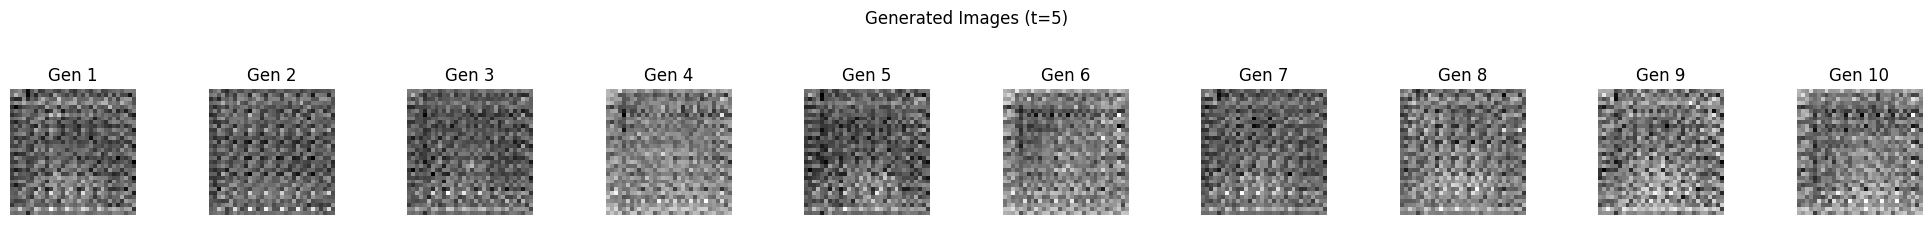

In [36]:
import matplotlib.pyplot as plt
import torch.distributions as distributions
import torchvision.transforms.functional as TF
import torchvision.transforms as transforms

# Move the model to the correct device
model.to(device)
# Set the model to evaluation mode
model.eval()

num_generated_images = 10
fig, axes = plt.subplots(1, num_generated_images, figsize=(num_generated_images * 2, 2))

# Ensure axes is iterable even for a single image
if num_generated_images == 1:
    axes = [axes]

# Define the normalization transform to scale from [0, 1] to [-1, 1]
normalize_transform = transforms.Normalize((0.5,), (0.5,))

with torch.no_grad(): # Disable gradient calculations for inference
    for i in range(num_generated_images):
        beta_dist = distributions.Beta(0.5, 0.5)
        initial_noisy_image_flat = beta_dist.sample(sample_shape=(input_dim,)).to(device)

        model_input_x = initial_noisy_image_flat.unsqueeze(0) # Shape (1, input_dim)

        # 3. Set t=5 for the model's conditioning
        model_input_t = torch.tensor([2.0], device=device)
        denoised_image_flat,_,_ = model(model_input_x, model_input_t)
        denoised_image = denoised_image_flat.view(1, 32, 32).cpu()

        denoised_image_pil = TF.to_pil_image(denoised_image.squeeze(0))

        axes[i].imshow(denoised_image_pil, cmap='gray')
        axes[i].axis('off') # Hide axes ticks and labels
        axes[i].set_title(f'Gen {i+1}')

plt.suptitle('Generated Images (t=5)', y=1.1) # Overall title for the figure
plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()